# Host Copilot: quick and full host search

Edit the input cell, then run all cells. The notebook runs both modes, saves candidate tables, displays the reference FITS with the EP error circle and optional optical transient (OT), and builds an ipyaladin view for each result.

Search geometry follows the batch rule: without an OT, use the EP center and `r_err + 10 arcsec`; with an OT, use the OT center and a 20-arcsec cone. The yellow dashed circle always shows the original EP error region.

In [1]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

from pathlib import Path
import math
import re
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from astropy.wcs import FITSFixedWarning, WCS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
from regions import CircleSkyRegion

REPO_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'host_copilot').is_dir()
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from host_copilot import (
    CircleLocalization,
    HostPipeline,
    SearchConfig,
    TransientContext,
)
from host_copilot.extraction import ImageRecovery

warnings.filterwarnings('ignore', category=FITSFixedWarning)

## Inputs

`R_ERR` may be a number in arcseconds or a string such as `"10''"`, `"10 arcsec"`, or `"3'"`. Set both OT coordinates to `None` when no OT is available.

In [2]:
NAME = 'EP260812a'
RA = 311.4377             # EP RA, deg (ICRS)
DEC = 14.1600              # EP Dec, deg (ICRS)
R_ERR = "10''"           # EP 90% error radius

O_RA = None        # OT RA, deg; use None if unavailable
O_DEC = None          # OT Dec, deg; use None if unavailable
OT_ERROR_ARCSEC = 0.5

TRANSIENT_REDSHIFT = None   # optional; use None if unknown
CLASSIFICATION = 'GRB'        # optional
FULL_Z_MAX = 0.1              # change to 0.3 if desired
OUTPUT_ROOT = REPO_ROOT / 'examples' / 'interactive_host_search' / NAME

In [3]:
def radius_arcsec(value):
    if isinstance(value, (int, float, np.number)):
        radius = float(value)
    else:
        text = str(value).strip().replace('arcseconds', 'arcsec').replace('arcsecond', 'arcsec')
        text = text.replace('arcminutes', 'arcmin').replace('arcminute', 'arcmin')
        match = re.fullmatch(r"([+]?(?:\d+(?:\.\d*)?|\.\d+))\s*(arcsec|arcmin|deg|\"|''|″|'|′|°)?", text, re.I)
        if match is None:
            raise ValueError(f'Cannot parse R_ERR={value!r}')
        number = float(match.group(1))
        token = (match.group(2) or 'arcsec').lower()
        unit = u.arcmin if token in {'arcmin', "'", '′'} else u.deg if token in {'deg', '°'} else u.arcsec
        radius = (number * unit).to_value(u.arcsec)
    if not math.isfinite(radius) or radius <= 0:
        raise ValueError('R_ERR must be positive and finite')
    return radius

if (O_RA is None) != (O_DEC is None):
    raise ValueError('O_RA and O_DEC must be supplied together')

r90 = radius_arcsec(R_ERR)
localization = CircleLocalization(RA, DEC, r90, confidence=0.90)
transient = TransientContext(
    name=NAME,
    localization=localization,
    optical_ra_deg=O_RA,
    optical_dec_deg=O_DEC,
    optical_error_arcsec=OT_ERROR_ARCSEC,
    redshift=TRANSIENT_REDSHIFT,
    classification=CLASSIFICATION,
)

if O_RA is not None:
    search_ra, search_dec, search_radius = O_RA, O_DEC, 20.0
    search_center_source = 'OT'
else:
    search_ra, search_dec, search_radius = RA, DEC, r90 + 10.0
    search_center_source = 'EP'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f'EP localization: ({RA:.6f}, {DEC:.6f}), r90={r90:g} arcsec')
print(f'Catalog cone: {search_center_source} ({search_ra:.6f}, {search_dec:.6f}), radius={search_radius:g} arcsec')

EP localization: (311.437700, 14.160000), r90=10 arcsec
Catalog cone: EP (311.437700, 14.160000), radius=20 arcsec


## Run quick and full searches

Quick mode uses REGALADE and `z < 0.1`. Full mode uses all configured providers, `z < FULL_Z_MAX`, retains unknown-redshift candidates, and performs image-source recovery. Provider failures remain visible as partial-result states.

In [4]:
pipelines = {}
results = {}
for mode in ('quick', 'full'):
    mode_dir = OUTPUT_ROOT / mode
    mode_dir.mkdir(parents=True, exist_ok=True)
    config = SearchConfig(
        mode=mode,
        z_max=0.1 if mode == 'quick' else FULL_Z_MAX,
        association_margin_arcsec=0.0,
        search_ra_deg=search_ra,
        search_dec_deg=search_dec,
        search_radius_arcsec=search_radius,
        cache_dir=mode_dir / '.host_copilot_cache',
        image_recovery=(mode == 'full'),
    )
    pipeline = HostPipeline(
        localization=localization,
        mode=mode,
        save_path=str(mode_dir),
    )
    result = pipeline.search(transient, config)
    result.to_csv(mode_dir / 'host_candidates.csv')
    pipelines[mode] = pipeline
    results[mode] = result
    states = {name: status.state for name, status in result.provider_status.items()}
    errors = {name: status.error for name, status in result.provider_status.items() if status.error}
    print(f'{mode}: {len(result.candidates)} candidates; complete={result.complete}; providers={states}')
    if errors:
        print('  provider errors:', errors)
    for warning in result.warnings:
        print('  warning:', warning)

quick: 0 candidates; complete=True; providers={'regalade': 'cached'}
Saved PS1 cutout to /Volumes/T7/Shared_Files/EP/Projects/Host_copilot/examples/interactive_host_search/EP260812a/full/ps1_r_ref.fits
full: 9 candidates; complete=True; providers={'regalade': 'cached', 'panstarrs': 'cached', 'legacy': 'cached', 'desi': 'cached', 'ned': 'cached', 'sdss': 'cached', 'gaia': 'cached', 'image': 'success'}


In [5]:
def candidate_summary(result, limit=20):
    frame = result.to_pandas()
    columns = [
        'rank', 'name', 'catalogs', 'redshift', 'redshift_kind',
        'separation_arcsec', 'optical_separation_arcsec',
        'inside_localization', 'footprint_overlap',
        'relative_probability', 'assessment',
    ]
    return frame[[column for column in columns if column in frame]].head(limit)

print('QUICK candidates')
display(candidate_summary(results['quick']))
print('FULL candidates')
display(candidate_summary(results['full']))

QUICK candidates


,rank,name,catalogs,redshift,redshift_kind,separation_arcsec,optical_separation_arcsec,inside_localization,footprint_overlap,relative_probability,assessment


FULL candidates


,rank,name,catalogs,redshift,redshift_kind,separation_arcsec,optical_separation_arcsec,inside_localization,footprint_overlap,relative_probability,assessment
0,1,WISEA J204544.89+140930.5,"[""ned"", ""panstarrs""]",None,unknown,5.893324,None,True,True,2.114916e-02,stellar_contaminant
1,2,image source 7,"[""image""]",None,unknown,5.471248,None,True,True,4.975942e-04,stellar_contaminant
2,3,PSO J311.4378+14.1572,"[""panstarrs"", ""image""]",None,unknown,10.171233,None,False,True,2.101801e-06,stellar_contaminant
3,4,PSO J311.4410+14.1556,"[""panstarrs""]",None,unknown,19.771145,None,False,False,4.620597e-10,outside_localization
4,5,PSO J311.4354+14.1631,"[""panstarrs"", ""image""]",None,unknown,13.825091,None,False,False,1.927795e-13,stellar_contaminant
5,6,PSO J311.4420+14.1583,"[""panstarrs"", ""image""]",None,unknown,16.286399,None,False,False,1.011279e-17,stellar_contaminant
6,7,PSO J311.4345+14.1559,"[""panstarrs"", ""image""]",None,unknown,18.482383,None,False,False,2.445290e-19,stellar_contaminant
7,8,PSO J311.4359+14.1555,"[""panstarrs"", ""image""]",None,unknown,17.350022,None,False,False,2.255089e-19,stellar_contaminant
8,9,image source 4,"[""image""]",None,unknown,16.561248,None,False,False,1.380467e-33,outside_localization


## Reference FITS overlays

Yellow dashed: EP 90% error circle. Magenta star: OT, when supplied. White dotted: actual catalog search cone. Candidate positions are overlaid separately for quick and full mode.

In [6]:
reference_dir = OUTPUT_ROOT / 'reference'
reference_config = SearchConfig(
    mode='full',
    search_ra_deg=search_ra,
    search_dec_deg=search_dec,
    search_radius_arcsec=search_radius,
    association_margin_arcsec=0.0,
    image_recovery=False,
)
full_cutout = results['full'].metadata.get('image_recovery', {}).get('cutout')
reference_path = Path(full_cutout) if full_cutout and Path(full_cutout).exists() else None
if reference_path is None:
    reference_path = ImageRecovery(reference_dir).get_reference_cutout(
        transient, reference_config
    )
print('Reference FITS:', reference_path)

Reference FITS: /Volumes/T7/Shared_Files/EP/Projects/Host_copilot/examples/interactive_host_search/EP260812a/full/ps1_r_ref.fits


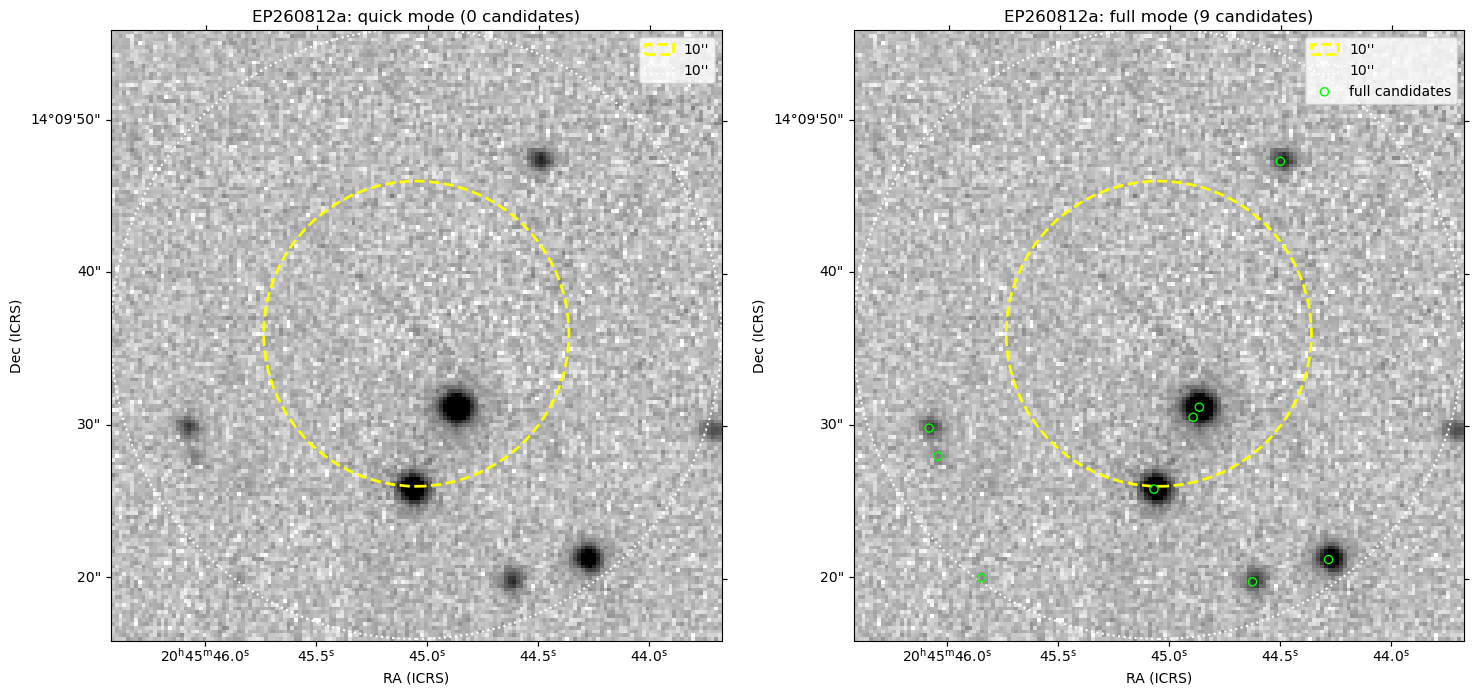

Saved: /Volumes/T7/Shared_Files/EP/Projects/Host_copilot/examples/interactive_host_search/EP260812a/reference_overlays.png


In [11]:
def read_fits_image(path):
    with fits.open(path, memmap=False) as hdul:
        for hdu in hdul:
            if hdu.data is None:
                continue
            data = np.asarray(hdu.data, dtype=float)
            while data.ndim > 2:
                data = data[0]
            if data.ndim == 2:
                return data, hdu.header.copy()
    raise ValueError(f'No 2-D image in {path}')

def add_sky_circle(axis, wcs, center, radius, **style):
    artist = CircleSkyRegion(center=center, radius=radius).to_pixel(wcs).as_artist(**style)
    axis.add_artist(artist)

if reference_path is None:
    print('No survey reference FITS is available for this position.')
else:
    data, header = read_fits_image(reference_path)
    wcs = WCS(header).celestial
    norm = ImageNormalize(
        data, interval=PercentileInterval(99.5), stretch=AsinhStretch()
    )
    figure = plt.figure(figsize=(15, 7))
    for panel, mode in enumerate(('quick', 'full'), start=1):
        axis = figure.add_subplot(1, 2, panel, projection=wcs)
        axis.imshow(data, origin='lower', cmap='gray_r', norm=norm)
        add_sky_circle(
            axis, wcs, localization.center, r90 * u.arcsec,
            edgecolor='yellow', facecolor='none', linestyle='--', linewidth=2,label=R_ERR
        )
        add_sky_circle(
            axis, wcs, SkyCoord(search_ra * u.deg, search_dec * u.deg),
            search_radius * u.arcsec, edgecolor='white', facecolor='none',
            linestyle=':', linewidth=1.5,label=R_ERR
        )
        if O_RA is not None:
            axis.scatter(
                [O_RA], [O_DEC], transform=axis.get_transform('world'),
                marker='*', s=180, facecolor='magenta', edgecolor='black',
                linewidth=0.8, label='OT', zorder=10,
            )
        candidates = results[mode].candidates
        if candidates:
            axis.scatter(
                [item.ra_deg for item in candidates],
                [item.dec_deg for item in candidates],
                transform=axis.get_transform('world'), marker='o', s=35,
                facecolor='none', edgecolor='cyan' if mode == 'quick' else 'lime',
                linewidth=1.0, label=f'{mode} candidates', zorder=8,
            )
        axis.set_title(f'{NAME}: {mode} mode ({len(candidates)} candidates)')
        axis.set_xlabel('RA (ICRS)')
        axis.set_ylabel('Dec (ICRS)')
        handles, labels = axis.get_legend_handles_labels()
        if handles:
            axis.legend(handles, labels, loc='upper right')
    figure.tight_layout()
    overlay_path = OUTPUT_ROOT / 'reference_overlays.png'
    figure.savefig(overlay_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', overlay_path)

## Quick-mode ipyaladin

Cyan symbols/ellipses are host candidates, the yellow dashed region is the EP error circle, the white dotted region is the catalog search cone, and the magenta table marker is the OT when available.

In [8]:
quick_aladin = pipelines['quick'].build_aladin(results['quick'])
quick_aladin

## Full-mode ipyaladin

In [9]:
full_aladin = pipelines['full'].build_aladin(results['full'])
full_aladin

In [10]:
print('Output directory:', OUTPUT_ROOT)
for path in sorted(OUTPUT_ROOT.rglob('*')):
    if path.is_file() and '.host_copilot_cache' not in path.parts:
        print(' -', path.relative_to(OUTPUT_ROOT))

Output directory: /Volumes/T7/Shared_Files/EP/Projects/Host_copilot/examples/interactive_host_search/EP260812a
 - ._full
 - ._quick
 - ._reference_overlays.png
 - full/._.host_copilot_cache
 - full/._host_candidates.csv
 - full/._image_candidates.csv
 - full/._image_detection_overlay.png
 - full/._ps1_r_ref.fits
 - full/._segmentation.fits
 - full/host_candidates.csv
 - full/image_candidates.csv
 - full/image_detection_overlay.png
 - full/ps1_r_ref.fits
 - full/segmentation.fits
 - quick/._.host_copilot_cache
 - quick/._host_candidates.csv
 - quick/host_candidates.csv
 - reference_overlays.png
